Implementation of Generative Adversarial Network (GAN)
Objective
To implement and train a basic Generative Adversarial Network (GAN) for image generation
using PyTorch or TensorFlow in Google Colab.
Part A – Setup and Understanding (Concept + Implementation)
Q1. Environment Setup
1. Create a new notebook in Google Colab.
2. Enable GPU acceleration.
3. Install required libraries.
4. Print the device configuration and verify GPU availability.
Q2. Dataset Preparation
1. Load the MNIST (or CIFAR-10) dataset.
2. Normalize the images to the range [-1, 1].
3. Use DataLoader with appropriate batch size.
4. Display a grid of sample training images.
Part B – GAN Architecture Design
Q3. Generator Network
1. Design a Generator network:
a. Input: Random noise vector (latent dimension = 100).
b. Output: 28×28 image.
2. Use appropriate activation functions.
3. Justify:
a. Why is Tanh used in the output layer?
Q4. Discriminator Network
1. Design a Discriminator network:
a. Input: Image (real or fake).
b. Output: Probability score.
2. Use suitable activation functions.
3. Explain:
a. Why is Sigmoid used in the final layer?
Part C – Training the GAN
Q5. Loss Function and Optimization
1. Define:
a. Binary Cross-Entropy Loss
b. Optimizers (Adam recommended)
2. Set learning rates and beta parameters.
3. Explain:
a. Why is GAN training considered a minimax game?
Q6. GAN Training Loop
Implement the training loop:
For each epoch:
1. Train Discriminator on:
a. Real images
b. Fake images (generated)
2. Train Generator to fool the discriminator.
3. Track:
a. Generator Loss
b. Discriminator Loss
Train for at least 30 epochs.
Part D – Analysis and Visualization
Q7. Generated Output
1. Generate 16 images after training.
2. Display them in a grid.
Q8. Loss Curve Analysis
1. Plot Generator and Discriminator loss curves.
Submission Requirements
1. Google Colab notebook (.ipynb)
2. Output screenshots of:
a. Generated images
b. Loss plots



```
Part A – Setup and Understanding
Q1. Environment Setup
To enable GPU in Colab, go to Edit > Notebook settings > Hardware accelerator > GPU.
```



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device configuration: {device}")

Device configuration: cpu


Q2. Dataset PreparationWe normalize images to the range $[-1, 1]$ because the Generator will use a Tanh activation function.

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 516kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.43MB/s]


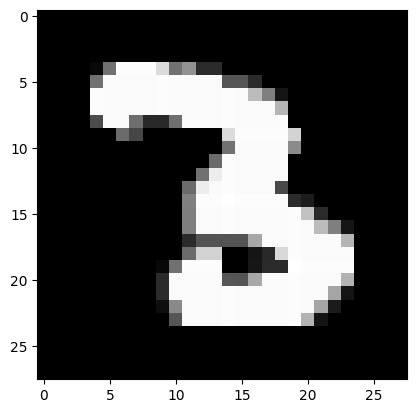

In [ ]:
# Image transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scales [0, 1] to [-1, 1]
])

# Load MNIST
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Display sample images
dataiter = iter(train_loader)
images, labels = next(dataiter)

def show_images(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img[0].numpy(), (1, 2, 0)), cmap='gray')
    plt.show()

show_images(images)

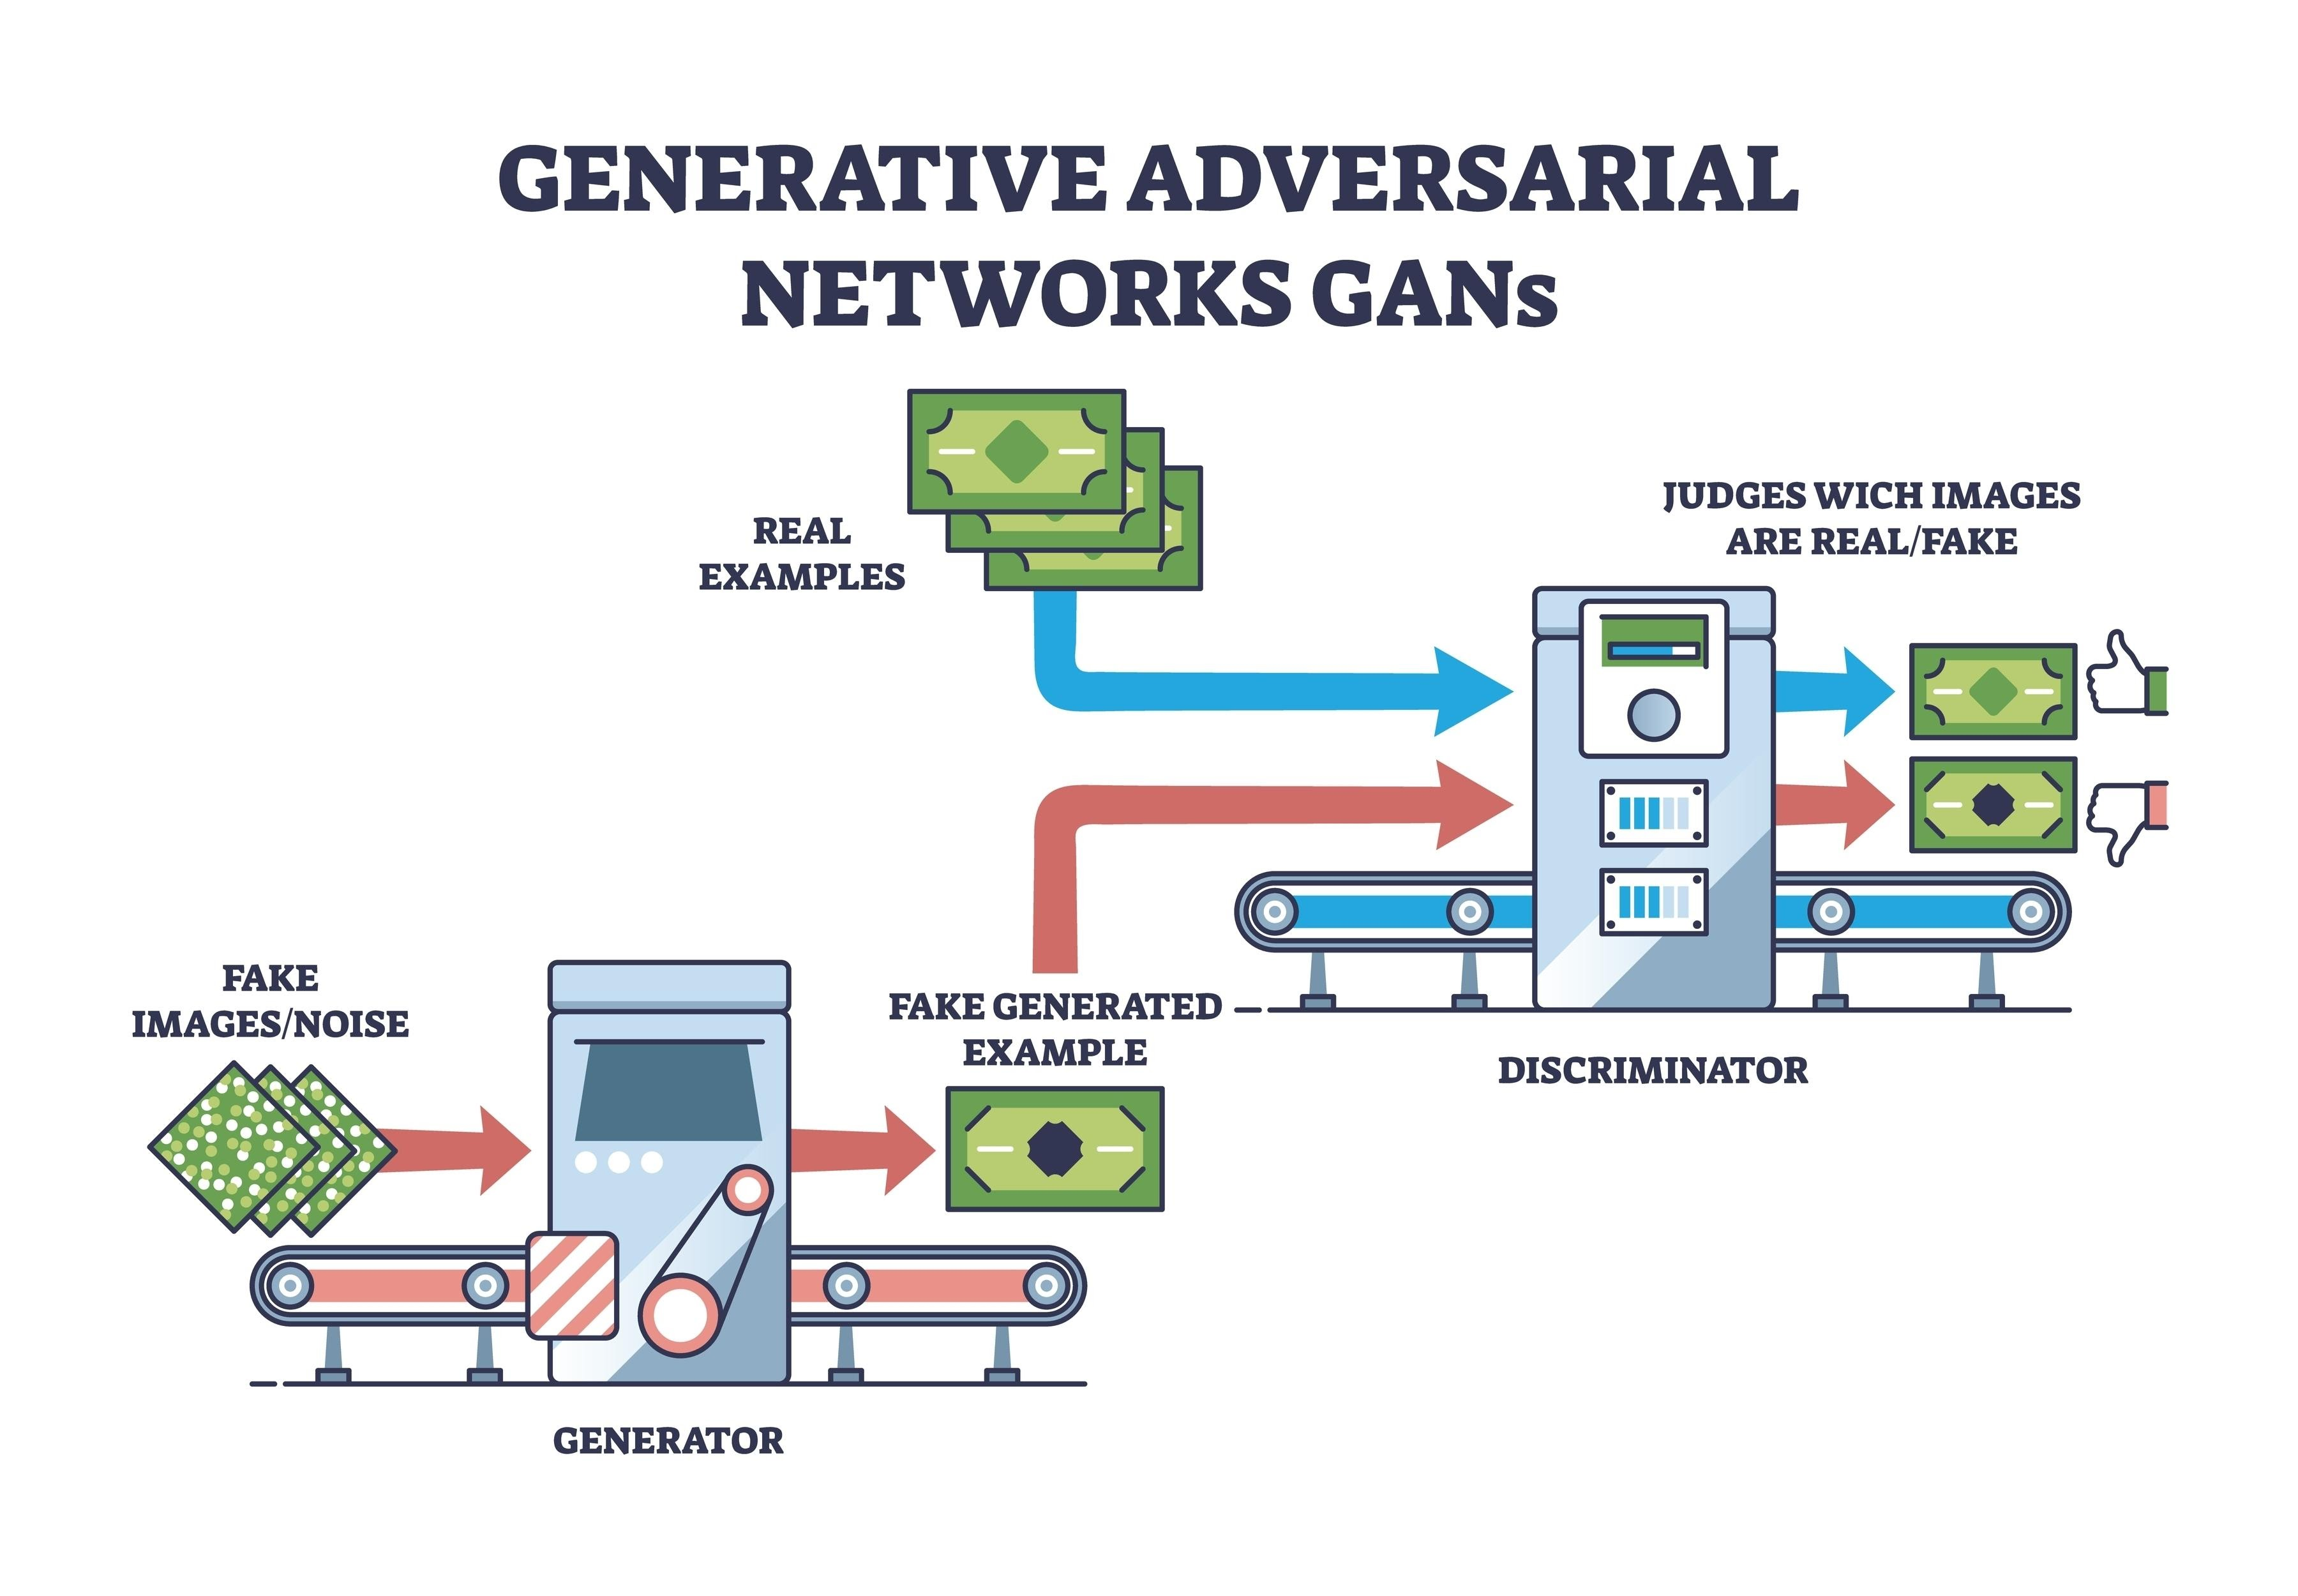

Q3. Generator NetworkThe Generator takes a latent noise vector and upsamples it into a $28 \times 28$ image.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim # You'll need this later for training!

In [10]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh() # Output layer
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

# Justification: Tanh is used in the output layer because its range is [-1, 1],
# matching our normalized dataset range and providing a stronger gradient than Sigmoid.

Q4. Discriminator Network
The Discriminator acts as a binary classifier (Real vs. Fake).

In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Output layer
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# Explain: Sigmoid is used in the final layer to squash the output into a probability
# score between 0 and 1, representing the likelihood that the input image is real.

# Part C – Training the GAN
Q5. Loss Function and Optimization
GANs use Binary Cross-Entropy (BCE) because the task is binary classification.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
lr = 0.0002
b1 = 0.5
b2 = 0.999

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

# Explain: GAN training is a minimax game because the Discriminator tries to maximize
# its ability to distinguish real/fake, while the Generator tries to minimize the
# probability that the Discriminator classifies its output as fake.

Q6. GAN Training Loop

In [15]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

epochs = 30
g_losses = []
d_losses = []

# Image transformations (normalize to [-1, 1] for GANs)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST Dataset
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# Data loader
batch_size = 64 # You can adjust this batch size
train_loader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(train_loader):

        real_imgs = imgs.to(device)
        valid = torch.ones(imgs.size(0), 1).to(device)
        fake = torch.zeros(imgs.size(0), 1).to(device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        gen_imgs = generator(z)

        real_loss = criterion(discriminator(real_imgs), valid)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        g_loss = criterion(discriminator(gen_imgs), valid) # Try to make D believe they are valid

        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if epoch % 10 == 0 or epoch == epochs-1:
        print(f"Epoch {epoch}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 467kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


Epoch 0/30 | D Loss: 0.5383 | G Loss: 1.1920
Epoch 10/30 | D Loss: 0.6560 | G Loss: 0.8024
Epoch 20/30 | D Loss: 0.4819 | G Loss: 1.2423
Epoch 29/30 | D Loss: 0.5169 | G Loss: 0.9081


# Part D – Analysis and Visualization
Q7. Generated Output

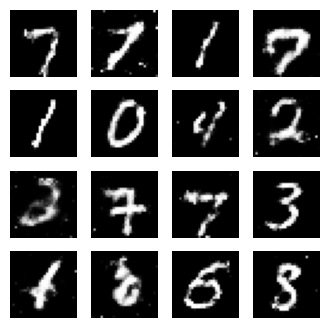

In [19]:
import matplotlib.pyplot as plt
z = torch.randn(16, latent_dim).to(device)
gen_imgs = generator(z).detach().cpu()

plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

Q8. Loss Curve Analysis

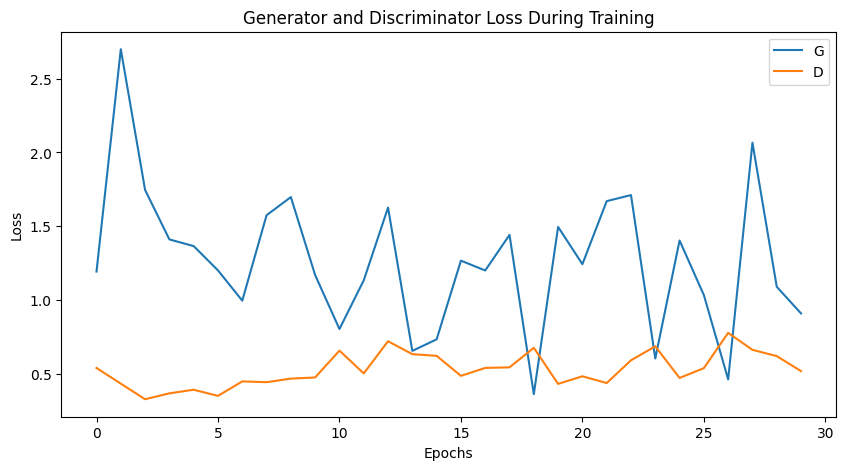

In [20]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(g_losses, label="G")
plt.plot(d_losses, label="D")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()